# Optimal Transport in linear ICA

#### In this notebook we present why anyone would use the slow OT Stiefel Manifold ICA (10 mins when dim=50, increases linearly with dimensions) over Fast ICA (<1 minute for dims=50).

### Experiment: FastICA Contrast Functions vs. Wasserstein OT-ICA

FastICA relies on scalar approximations (contrast functions like `logcosh`) that make specific geometric assumptions about the data. To demonstrate why the higher computational cost of Wasserstein OT-ICA (W-ICA) is justified, we test three distributions designed to expose the blind spots of parametric summaries:



* **Exponential (The Asymmetric Blindspot):** FastICA's default contrast functions are symmetric (even functions) and mathematically blind to skewness. W-ICA compares the entire Cumulative Distribution Function (CDF), natively capturing asymmetric geometry without needing to specify an odd moment.
* **Student's t, df=7 (The Near-Gaussian Trap):** Because it is very close to a perfect Gaussian, FastICA's moment approximations struggle to distinguish its subtle heavy tails from sample noise. W-ICA measures the exact volume of probability mass in the tails rather than relying on a summarized scalar.
* **Uniform (The Hard Boundary):** A sub-Gaussian distribution with negative kurtosis and absolute cutoffs. FastICA's continuous, smooth approximations struggle with sharp boundaries, whereas the Wasserstein metric natively maps flat geometries and bounded supports.

In [1]:
import numpy as np
import torch
import pandas as pd
import time
from sklearn.decomposition import FastICA
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# 1. Helpers & Data Generation
# ==========================================

def amari_error(W_est, A_true):
    if W_est is None or np.any(np.isnan(W_est)):
        return np.nan
        
    P = np.abs(W_est @ A_true)
    n = P.shape[0]
    
    row_sum = np.sum(P, axis=1)
    row_max = np.max(P, axis=1)
    term1 = np.sum((row_sum / row_max) - 1)
    
    col_sum = np.sum(P, axis=0)
    col_max = np.max(P, axis=0)
    term2 = np.sum((col_sum / col_max) - 1)
    
    return (term1 + term2) / (2 * n)

def generate_dataset(n_dim, n_samples, dist_type='laplace', seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    if dist_type == 'laplace':
        # Super-Gaussian, sharp peak
        sources = [np.random.laplace(0, 1, n_samples) for _ in range(n_dim)]
    elif dist_type == 'uniform':
        # Sub-Gaussian, bounded, negative kurtosis
        sources = [np.random.uniform(-np.sqrt(3), np.sqrt(3), n_samples) for _ in range(n_dim)]
    elif dist_type == 'exponential':
        # Highly skewed, asymmetric
        sources = [np.random.exponential(1.0, n_samples) - 1.0 for _ in range(n_dim)]
    elif dist_type == 'student_t':
        # Near-Gaussian, subtle heavy tails
        df = 7
        sources = [np.random.standard_t(df, n_samples) / np.sqrt(df / (df - 2)) for _ in range(n_dim)]
    else:
        raise ValueError("Unknown distribution type")
        
    S = np.stack(sources)
    
    # Well-conditioned mixing matrix
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

In [3]:
# ==========================================
# 2. Parallel Worker Function
# ==========================================

def run_distribution_trial(dim, trial, n_samples, dist_type):
    torch.set_num_threads(1) # Prevent thread explosion
    trial_results = []
    
    X_torch, A_true = generate_dataset(n_dim=dim, n_samples=n_samples, dist_type=dist_type, seed=trial)
    X_np = X_torch.numpy()
    
    # --- FastICA ---
    t0_fast = time.perf_counter()
    try:
        fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true)
    except Exception:
        score_fast = np.nan
    t_fast_total = time.perf_counter() - t0_fast
        
    trial_results.append({
        'Distribution': dist_type,
        'Dimension': dim, 
        'Method': 'FastICA', 
        'Amari Error': score_fast,
        'Total Time (s)': t_fast_total
    })
    
    # --- W-ICA (Stiefel) ---
    t0_wass = time.perf_counter()
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        n_restarts = dim * 4 if dim * 4 < 150 else 150
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=200, n_restarts=n_restarts)
            extracted_ws.append(w)
        W_deflation_init = torch.stack(extracted_ws)
        
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, max_iter=200, lr=1.0, init_w=W_deflation_init, optimizer='stiefel'
        )
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
    except Exception:
        score_wass = np.nan
    t_wass_total = time.perf_counter() - t0_wass
        
    trial_results.append({
        'Distribution': dist_type,
        'Dimension': dim, 
        'Method': 'W-ICA (Stiefel)', 
        'Amari Error': score_wass,
        'Total Time (s)': t_wass_total
    })
    
    return trial_results

In [ ]:
# ==========================================
# 3. Main Execution
# ==========================================
DIMENSIONS = [10, 20, 30]
DISTRIBUTIONS = ['laplace', 'exponential', 'uniform', 'student_t_df_7']
N_SAMPLES = 5000
N_TRIALS = 5

In [5]:

tasks = [(dim, trial, N_SAMPLES, dist) for dist in DISTRIBUTIONS for dim in DIMENSIONS for trial in range(N_TRIALS)]

results_nested = Parallel(n_jobs=12)(
    delayed(run_distribution_trial)(dim, trial, n_samples, dist) 
    for dim, trial, n_samples, dist in tqdm(tasks, desc="Running Multi-Dist Trials")
)

results = [item for sublist in results_nested for item in sublist]
df = pd.DataFrame(results)

# Display tabular summary
summary_table = df.groupby(['Distribution', 'Dimension', 'Method'])['Amari Error'].mean().unstack().round(4)
display(summary_table)

--- The Contrast Function Weakness Showdown ---


Running Multi-Dist Trials:   0%|          | 0/60 [00:00<?, ?it/s]

Method                  FastICA  W-ICA (Stiefel)
Distribution Dimension                          
exponential  10          0.1800           0.2373
             20          0.2806           0.3603
             30          0.4326           0.4580
laplace      10          0.1183           0.1098
             20          0.2324           0.2208
             30          0.3653           0.3489
student_t    10          0.2070           0.2089
             20          0.4665           0.4785
             30          0.7239           0.8484
uniform      10          0.0769           0.0559
             20          0.1635           0.1179
             30          0.2555           0.1877

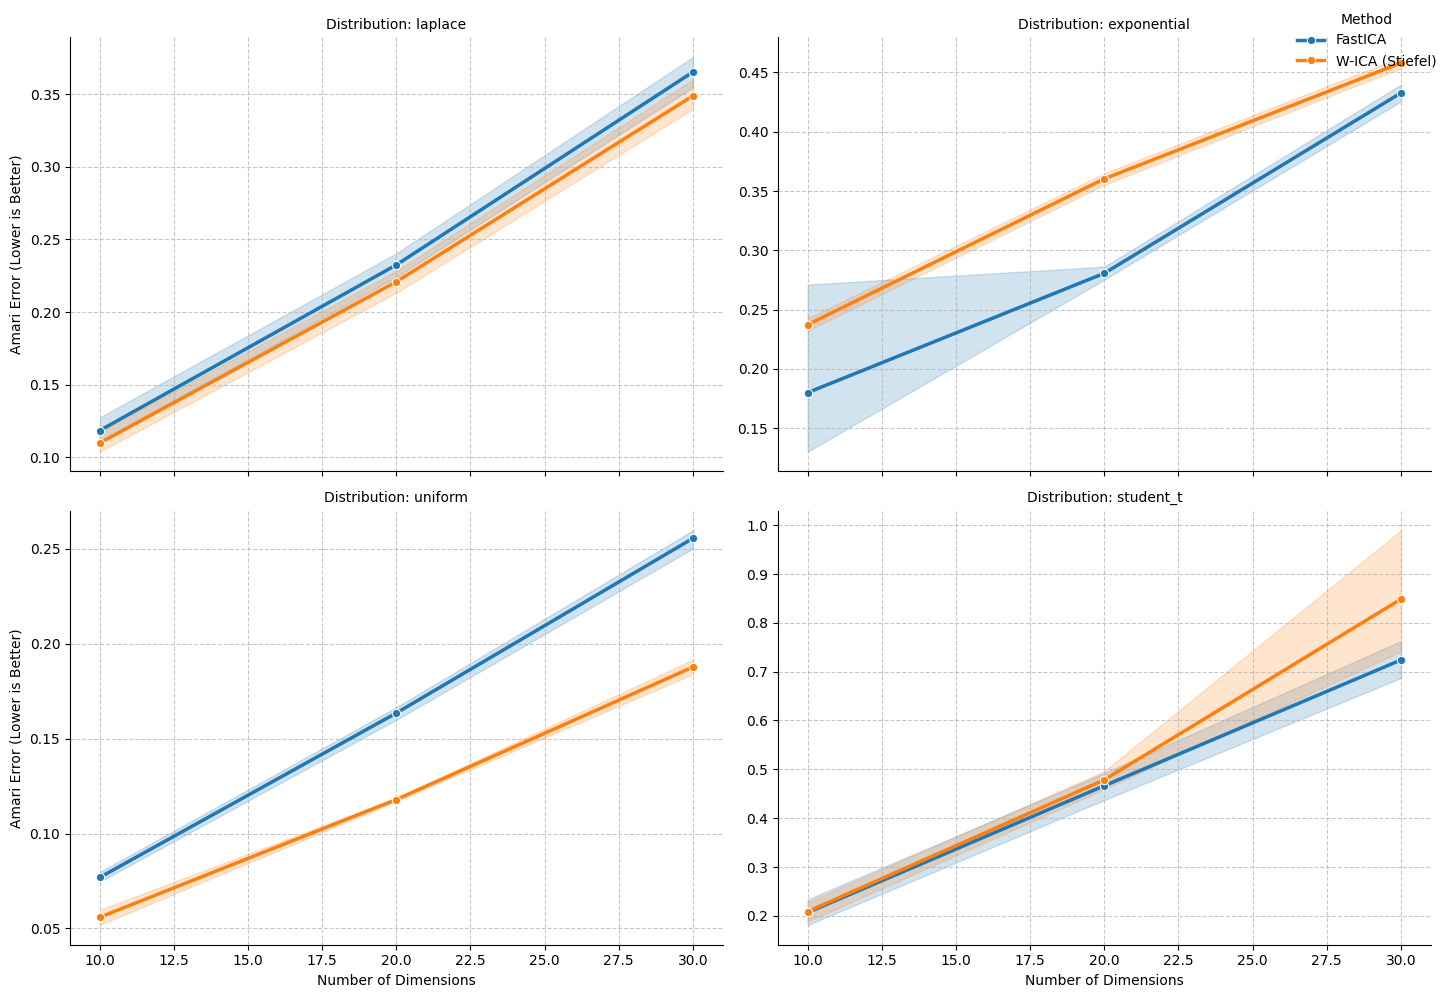

Method                  FastICA  W-ICA (Stiefel)
Distribution Dimension                          
exponential  10          0.1800           0.2373
             20          0.2806           0.3603
             30          0.4326           0.4580
laplace      10          0.1183           0.1098
             20          0.2324           0.2208
             30          0.3653           0.3489
student_t    10          0.2070           0.2089
             20          0.4665           0.4785
             30          0.7239           0.8484
uniform      10          0.0769           0.0559
             20          0.1635           0.1179
             30          0.2555           0.1877

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 4. Multi-Distribution Visualization
# ==========================================

# 1. Pivot the data to get one mean Amari error per distribution, method, and dimension
# Seaborn's FacetGrid will automatically handle the trials/error bars

g = sns.FacetGrid(df, col="Distribution", col_wrap=2, height=5, aspect=1.3, sharey=False)

# 2. Map the lineplot to each facet.
# FacetGrid maps a standard seaborn lineplot (data=df, x=..., y=..., hue=...)
# while holding 'col' constant.
g.map_dataframe(
    sns.lineplot, 
    x="Dimension", 
    y="Amari Error", 
    hue="Method", 
    marker="o", 
    linewidth=2.5
)

# 3. Titles and Labels
g.set_axis_labels("Number of Dimensions", "Amari Error (Lower is Better)")
g.set_titles("Distribution: {col_name}")

# 4. Format the graphs
for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.7)
    # Optional: Log scale helps see subtle differences near Gaussian 
    # ax.set_yscale('log') 

# 5. Add a single legend for the entire grid
g.add_legend(title="Method", loc='upper right')

plt.tight_layout()
plt.show()

# Display mean table one last time for context
display(df.groupby(['Distribution', 'Dimension', 'Method'])['Amari Error'].mean().unstack().round(4))